In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [49]:
df = pd.read_csv("global_food_security_intelligence.csv")
print('shape:', df.shape)
df.head()

shape: (5208, 57)


,country_code,iso3,country_name,year,region,income_group,lending_type,capital_city,latitude,longitude,...,food_crop_production_gap,protein_adequacy_score,agriculture_dependence_index,undernourishment_yoy_change_pp,row_completeness_pct,country_iso3,data_version,compiled_date,source_wb,source_fao
0,ABW,ABW,Aruba,2000,Latin America & Caribbean,High income,Not classified,Oranjestad,12.5167,-70.0167,...,NaN,NaN,5.56,NaN,33.3,AW,v1.0,2026-04-08,World Bank WDI API,FAOSTAT Bulk Download
1,ABW,ABW,Aruba,2001,Latin America & Caribbean,High income,Not classified,Oranjestad,12.5167,-70.0167,...,NaN,NaN,5.56,NaN,33.3,AW,v1.0,2026-04-08,World Bank WDI API,FAOSTAT Bulk Download
2,ABW,ABW,Aruba,2002,Latin America & Caribbean,High income,Not classified,Oranjestad,12.5167,-70.0167,...,NaN,NaN,5.56,NaN,33.3,AW,v1.0,2026-04-08,World Bank WDI API,FAOSTAT Bulk Download
3,ABW,ABW,Aruba,2003,Latin America & Caribbean,High income,Not classified,Oranjestad,12.5167,-70.0167,...,NaN,NaN,5.56,NaN,33.3,AW,v1.0,2026-04-08,World Bank WDI API,FAOSTAT Bulk Download
4,ABW,ABW,Aruba,2004,Latin America & Caribbean,High income,Not classified,Oranjestad,12.5167,-70.0167,...,NaN,NaN,5.56,NaN,33.3,AW,v1.0,2026-04-08,World Bank WDI API,FAOSTAT Bulk Download


In [50]:
display(df.info())
display(df.describe(include='all').T.head(20))

print("n/Missing Values")
display(df.isnull().sum().sort_values(ascending=False).head(20))

print('Duplicate Rows:', df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5208 entries, 0 to 5207
Data columns (total 57 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   country_code                           5208 non-null   object 
 1   iso3                                   5208 non-null   object 
 2   country_name                           5208 non-null   object 
 3   year                                   5208 non-null   int64  
 4   region                                 5208 non-null   object 
 5   income_group                           5208 non-null   object 
 6   lending_type                           5208 non-null   object 
 7   capital_city                           5064 non-null   object 
 8   latitude                               5064 non-null   float64
 9   longitude                              5064 non-null   float64
 10  agricultural_land_pct                  5002 non-null   float64
 11  arab

None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
country_code,5208,217,ZWE,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN
iso3,5208,217,ZWE,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country_name,5208,217,Zimbabwe,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year,5208.0,NaN,NaN,NaN,2011.5,6.922851,2000.0,2005.75,2011.5,2017.25,2023.0
region,5208,7,Europe & Central Asia,1392,NaN,NaN,NaN,NaN,NaN,NaN,NaN
income_group,5208,5,High income,2064,NaN,NaN,NaN,NaN,NaN,NaN,NaN
lending_type,5208,4,Not classified,1728,NaN,NaN,NaN,NaN,NaN,NaN,NaN
capital_city,5064,211,Harare,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN
latitude,5064.0,NaN,NaN,NaN,18.889009,24.155822,-41.2865,4.1742,17.3,40.0495,64.1836
longitude,5064.0,NaN,NaN,NaN,19.139549,70.231002,-175.216,-15.1804,19.2595,50.5354,179.089567


n/Missing Values


fao_child_wasting_millions               4869
fao_severe_food_insecure_millions        4431
fao_low_birthweight_millions             4410
stunting_prevalence_pct                  4363
fao_mod_severe_food_insecure_millions    4217
fao_severe_food_insecurity_pct           4178
poverty_headcount_pct                    3387
fao_child_stunting_millions              3349
fao_undernourishment_pct                 2598
fao_safe_water_pct                       2445
fao_cereal_import_dependency_pct         1719
fao_protein_supply_g_per_day             1657
fao_fat_supply_g_per_day                 1657
fao_animal_protein_g_per_day             1657
protein_adequacy_score                   1657
fao_child_stunting_pct                   1560
undernourishment_yoy_change_pp           1546
fao_dietary_energy_adequacy_pct          1538
undernourishment_pct                     1377
undernourished_pop_millions              1334
dtype: int64

Duplicate Rows: 0


In [51]:
# Missing value percentage
missing_pct = (df.isnull().mean()*100).sort_values(ascending=False)
df.head()

,country_code,iso3,country_name,year,region,income_group,lending_type,capital_city,latitude,longitude,...,food_crop_production_gap,protein_adequacy_score,agriculture_dependence_index,undernourishment_yoy_change_pp,row_completeness_pct,country_iso3,data_version,compiled_date,source_wb,source_fao
0,ABW,ABW,Aruba,2000,Latin America & Caribbean,High income,Not classified,Oranjestad,12.5167,-70.0167,...,NaN,NaN,5.56,NaN,33.3,AW,v1.0,2026-04-08,World Bank WDI API,FAOSTAT Bulk Download
1,ABW,ABW,Aruba,2001,Latin America & Caribbean,High income,Not classified,Oranjestad,12.5167,-70.0167,...,NaN,NaN,5.56,NaN,33.3,AW,v1.0,2026-04-08,World Bank WDI API,FAOSTAT Bulk Download
2,ABW,ABW,Aruba,2002,Latin America & Caribbean,High income,Not classified,Oranjestad,12.5167,-70.0167,...,NaN,NaN,5.56,NaN,33.3,AW,v1.0,2026-04-08,World Bank WDI API,FAOSTAT Bulk Download
3,ABW,ABW,Aruba,2003,Latin America & Caribbean,High income,Not classified,Oranjestad,12.5167,-70.0167,...,NaN,NaN,5.56,NaN,33.3,AW,v1.0,2026-04-08,World Bank WDI API,FAOSTAT Bulk Download
4,ABW,ABW,Aruba,2004,Latin America & Caribbean,High income,Not classified,Oranjestad,12.5167,-70.0167,...,NaN,NaN,5.56,NaN,33.3,AW,v1.0,2026-04-08,World Bank WDI API,FAOSTAT Bulk Download


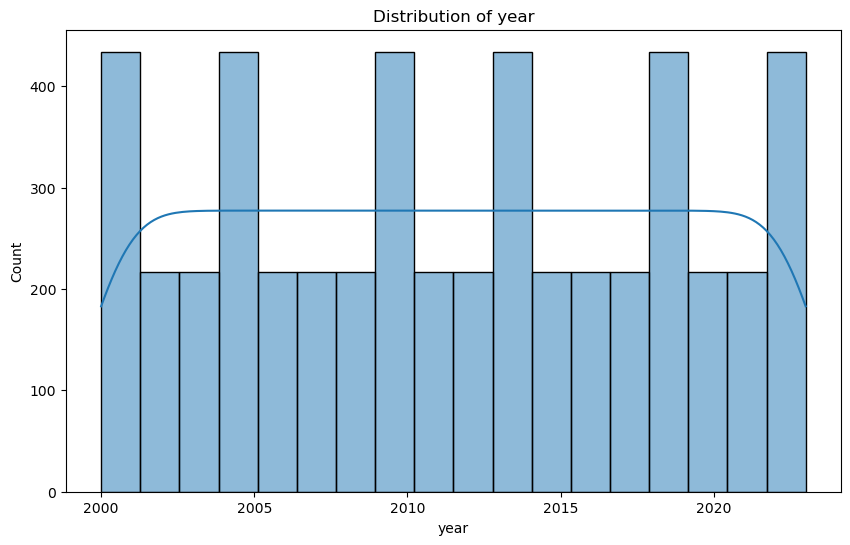

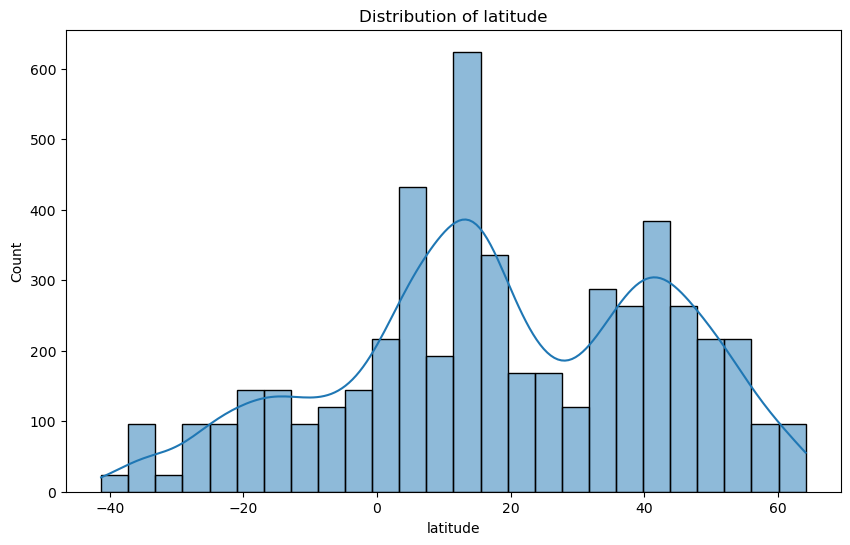

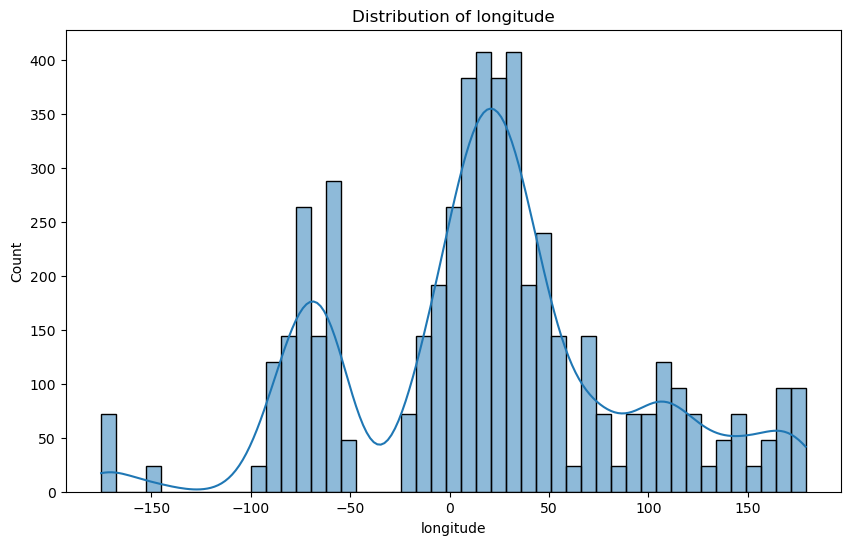

In [52]:
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols[:3]:
    plt.figure(figsize=(10,6))
    sns.histplot(df[col].dropna(), kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

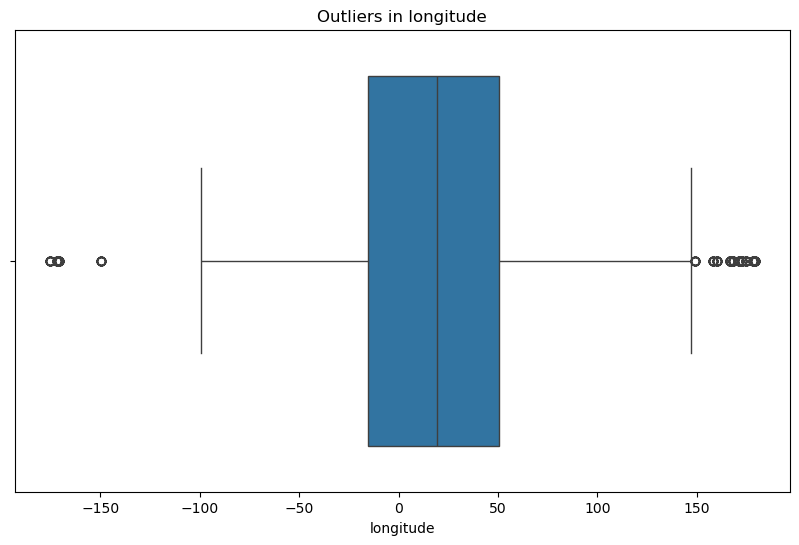

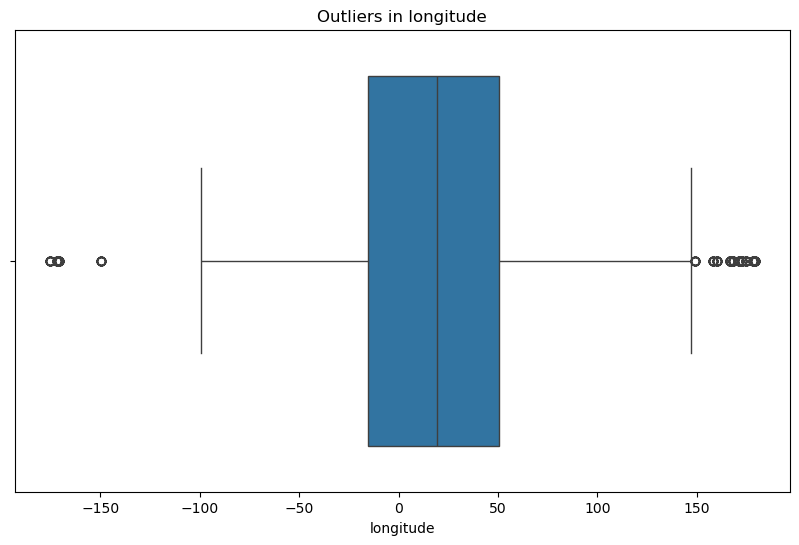

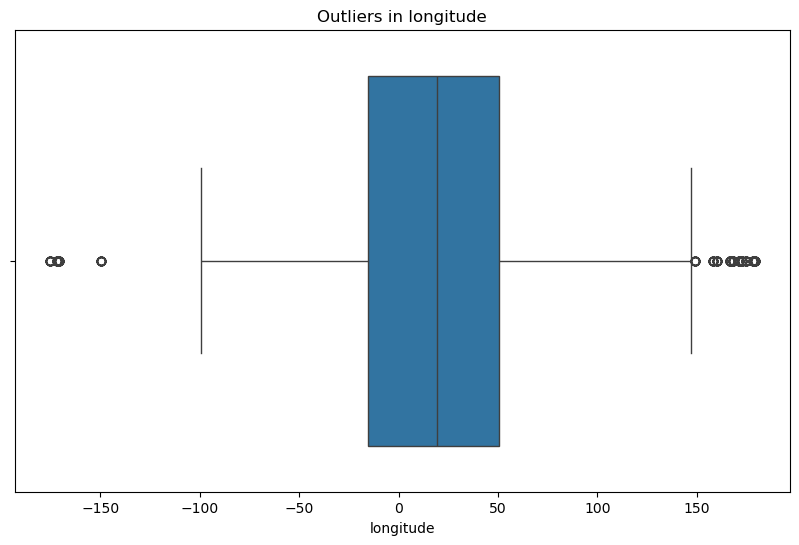

In [53]:
# Outlier Detection
for i in numeric_cols[:3]:
    plt.figure(figsize=(10,6))
    sns.boxplot(x=df[col])
    plt.title(f'Outliers in {col}')
    plt.show()
    

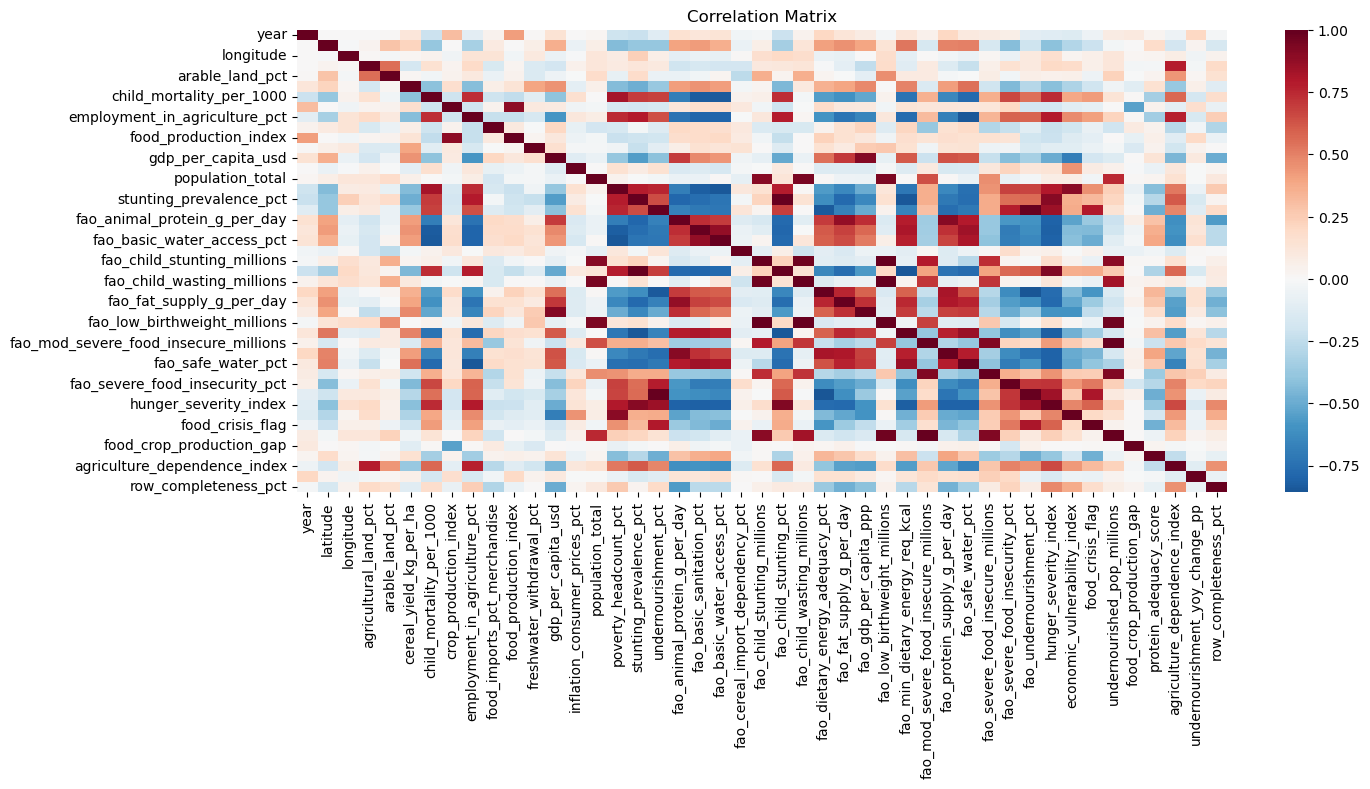

In [54]:
corr = df.select_dtypes(include=np.number).corr()
plt.figure(figsize=(15,6))
sns.heatmap(corr, cmap='RdBu_r', center=0)
plt.title('Correlation Matrix')
plt.show()

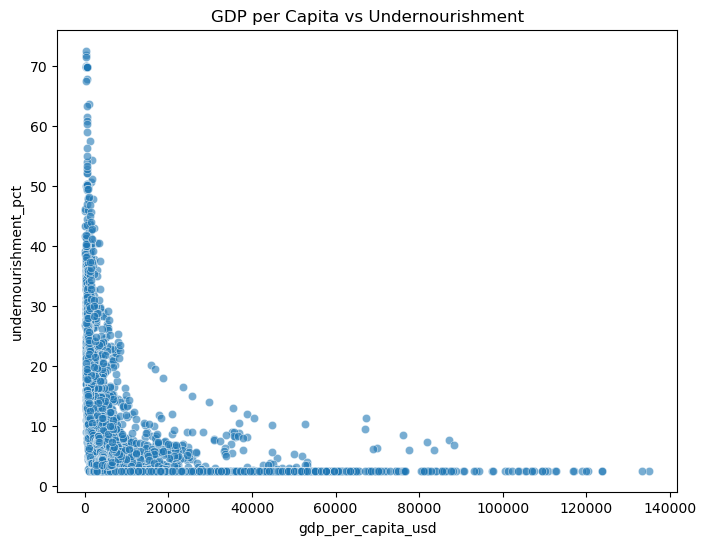

In [55]:
# Bivariate Analysis
if {"gdp_per_capita_usd", "undernourishment_pct"}.issubset(df.columns):
    plt.figure(figsize=(8, 6))
    sns.scatterplot(
        data=df,
        x="gdp_per_capita_usd",
        y="undernourishment_pct",
        alpha=0.6
    )
    plt.title('GDP per Capita vs Undernourishment')
    plt.show()

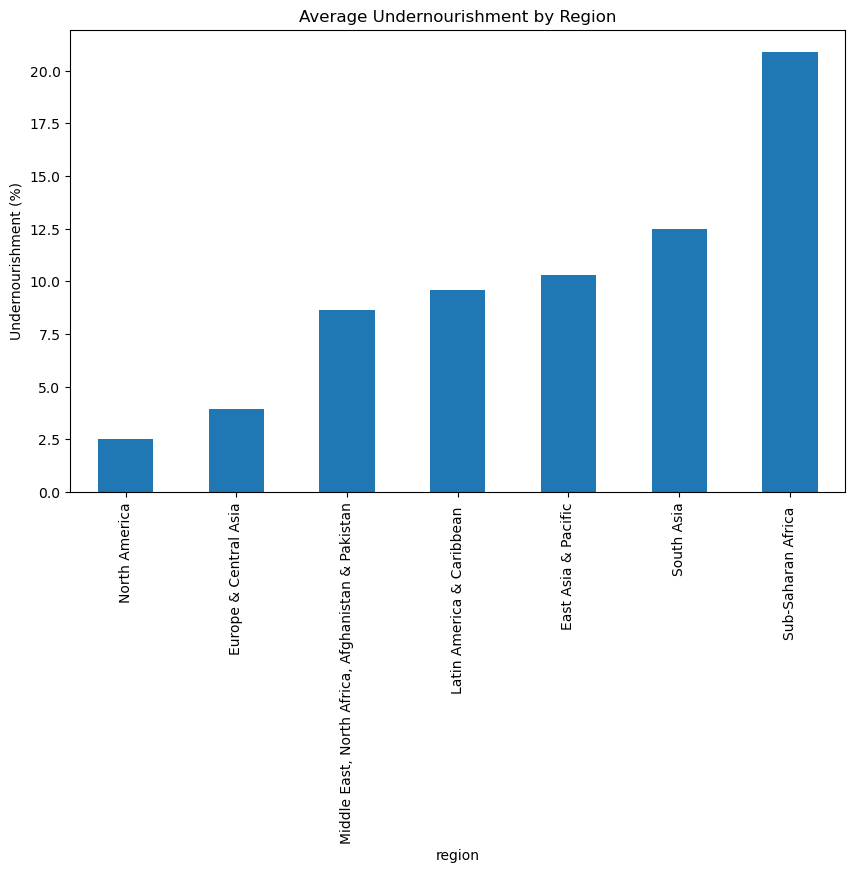

In [56]:
# Category-wise Comparisons
if "region" in df.columns and "undernourishment_pct" in df.columns:
    regional = df.groupby("region")["undernourishment_pct"].mean().sort_values()
    plt.figure(figsize=(10,6))
    regional.plot(kind='bar')
    plt.xticks(rotation=90)
    plt.title('Average Undernourishment by Region')
    plt.ylabel('Undernourishment (%)')
    plt.show()

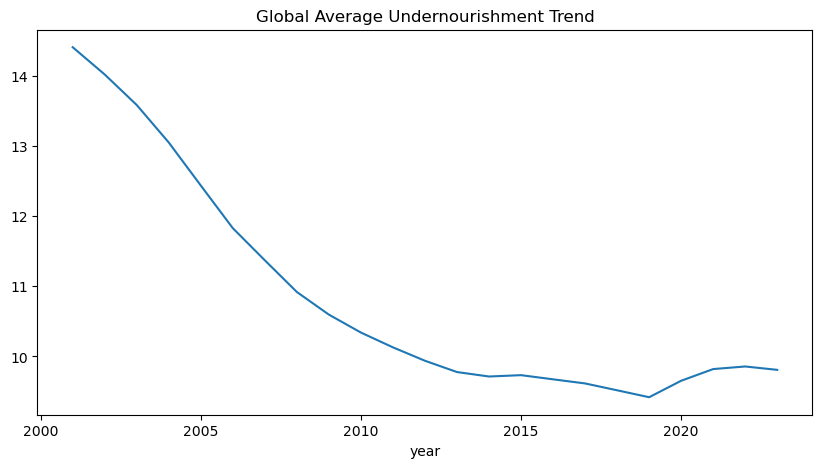

In [57]:
# Time-Series Analysis
if {"year", "undernourishment_pct"}.issubset(df.columns):
    yearly = df.groupby("year")["undernourishment_pct"].mean()

    plt.figure(figsize=(10,5))
    yearly.plot()
    plt.title("Global Average Undernourishment Trend")
    plt.show()


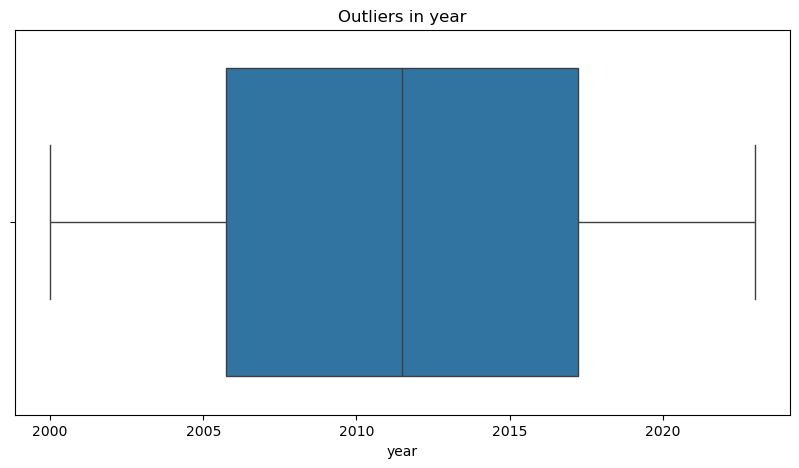

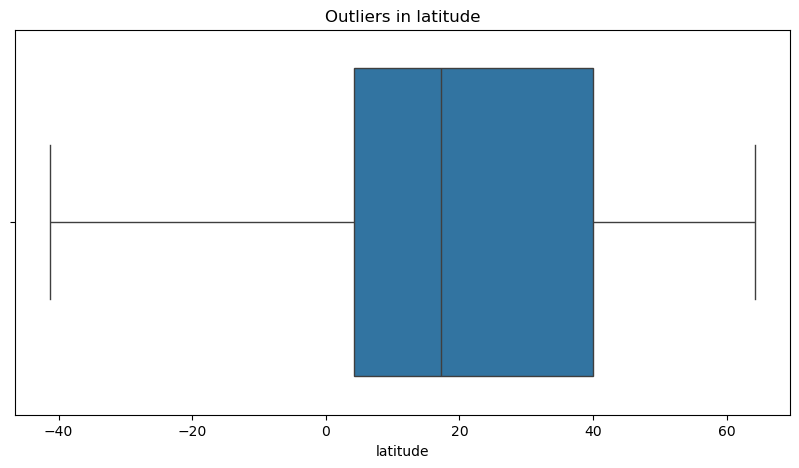

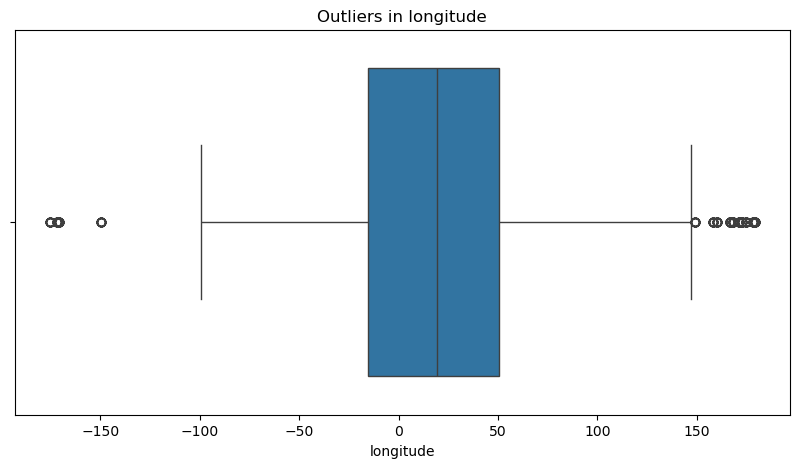

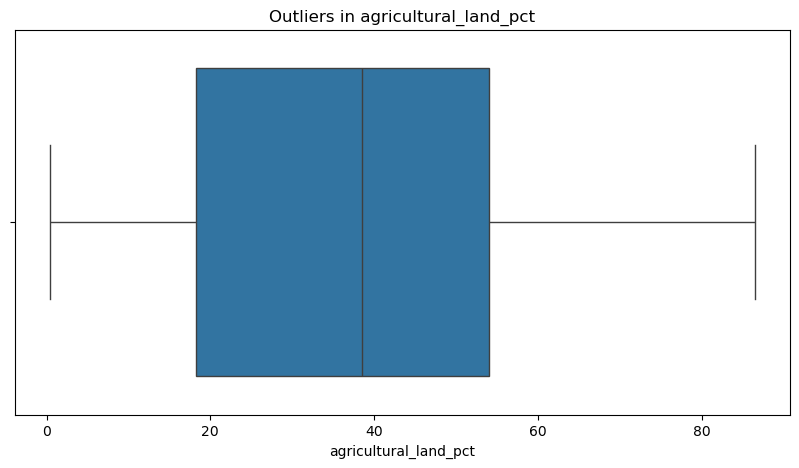

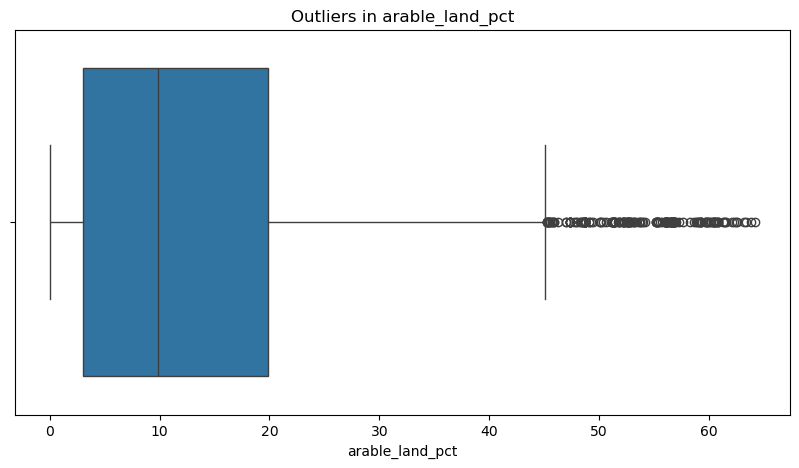

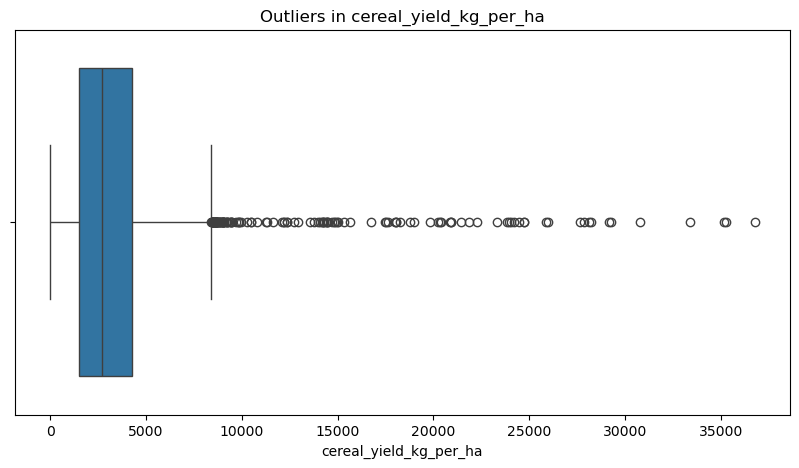

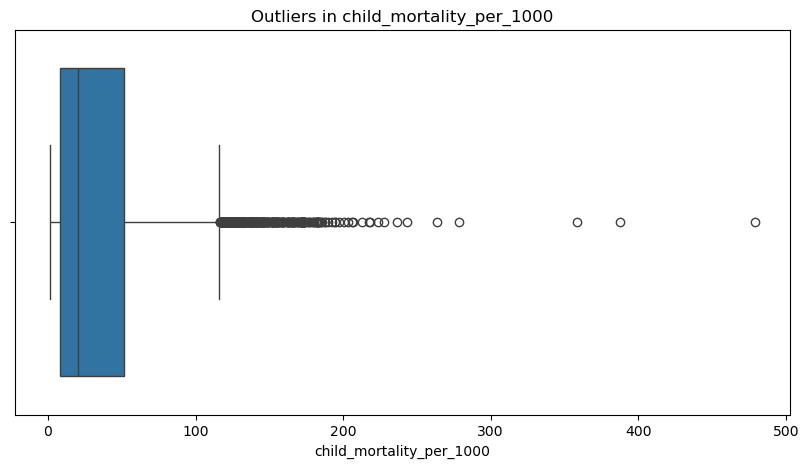

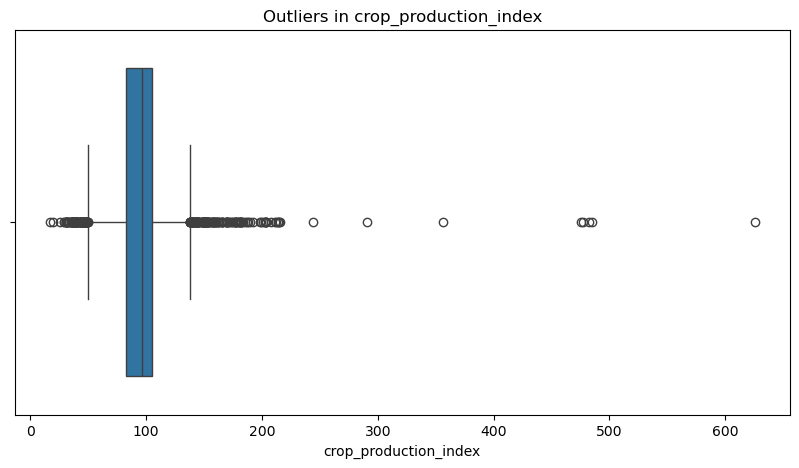

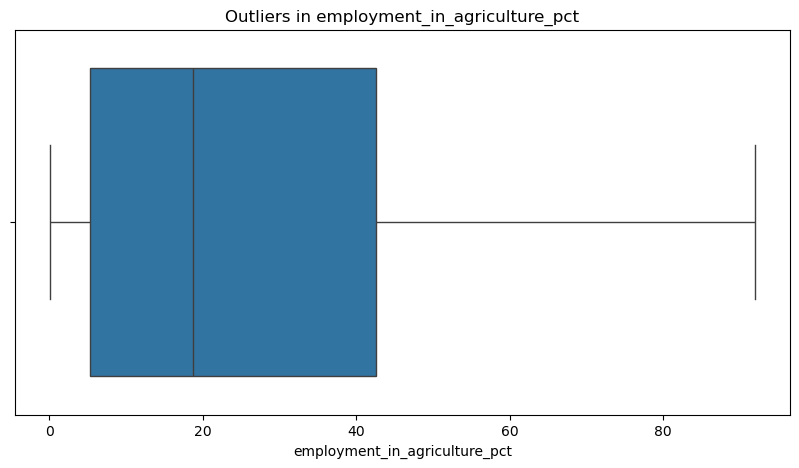

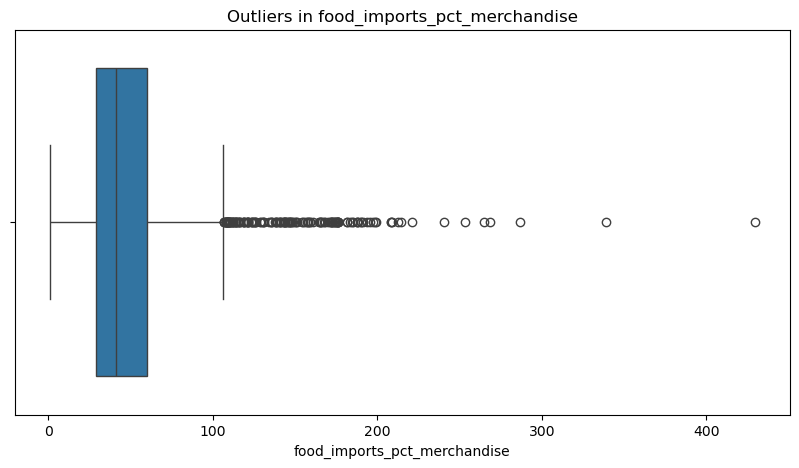

In [58]:
# Improved outlier analysis
# Improved Outlier Detection
numeric_cols =  df.select_dtypes(include=np.number).columns

for col in numeric_cols[:10]:
    plt.figure(figsize=(10, 5))
    sns.boxplot(x=df[col].dropna())
    plt.title(f'Outliers in {col}')
    plt.xlabel(col)
    plt.show()

In [59]:
# Create a KPI summary
kpi_cols = [
    "agricultural_land_pct",
    "arable_land_pct",
    "cereal_yield_kg_per_ha",
    "crop_production_index",
    "food_production_index",
    "employment_in_agriculture_pct",
    "food_imports_pct_merchandise",
    "undernourishment_pct",
    "food_crop_production_gap",
    "agriculture_dependence_index"
]
kpi_summary = df[kpi_cols].agg(["mean", "median", "min", "max"]).T
display(kpi_summary)

,mean,median,min,max
agricultural_land_pct,37.260159,38.504155,0.436116,86.475816
arable_land_pct,13.814459,9.886758,0.043141,64.146885
cereal_yield_kg_per_ha,3317.106949,2682.800000,0.100000,36761.900000
crop_production_index,94.955577,95.990000,17.000000,625.430000
food_production_index,94.246534,96.530000,17.000000,502.140000
employment_in_agriculture_pct,25.955071,18.738900,0.079580,91.937552
food_imports_pct_merchandise,48.006711,41.102967,1.127673,429.359095
undernourishment_pct,10.836831,6.200000,2.500000,72.500000
food_crop_production_gap,-0.709042,0.060000,-170.740000,119.110000
agriculture_dependence_index,29.066655,28.785000,0.000000,84.740000


In [60]:
# Analyze Ukraine specifically
ukraine = df[df["country_name"].str.lower() == "ukraine"].copy()

print("Ukraine observations:", len(ukraine))
display(ukraine.head())

Ukraine observations: 24


,country_code,iso3,country_name,year,region,income_group,lending_type,capital_city,latitude,longitude,...,food_crop_production_gap,protein_adequacy_score,agriculture_dependence_index,undernourishment_yoy_change_pp,row_completeness_pct,country_iso3,data_version,compiled_date,source_wb,source_fao
4824,UKR,UKR,Ukraine,2000,Europe & Central Asia,Upper middle income,IBRD,Kiev,50.4536,30.5038,...,12.88,NaN,44.90,NaN,75.0,UA,v1.0,2026-04-08,World Bank WDI API,FAOSTAT Bulk Download
4825,UKR,UKR,Ukraine,2001,Europe & Central Asia,Upper middle income,IBRD,Kiev,50.4536,30.5038,...,11.02,100.0,44.65,NaN,91.7,UA,v1.0,2026-04-08,World Bank WDI API,FAOSTAT Bulk Download
4826,UKR,UKR,Ukraine,2002,Europe & Central Asia,Upper middle income,IBRD,Kiev,50.4536,30.5038,...,12.74,100.0,44.45,-0.2,83.3,UA,v1.0,2026-04-08,World Bank WDI API,FAOSTAT Bulk Download
4827,UKR,UKR,Ukraine,2003,Europe & Central Asia,Upper middle income,IBRD,Kiev,50.4536,30.5038,...,13.44,100.0,44.09,0.0,83.3,UA,v1.0,2026-04-08,World Bank WDI API,FAOSTAT Bulk Download
4828,UKR,UKR,Ukraine,2004,Europe & Central Asia,Upper middle income,IBRD,Kiev,50.4536,30.5038,...,9.88,100.0,43.80,0.0,83.3,UA,v1.0,2026-04-08,World Bank WDI API,FAOSTAT Bulk Download


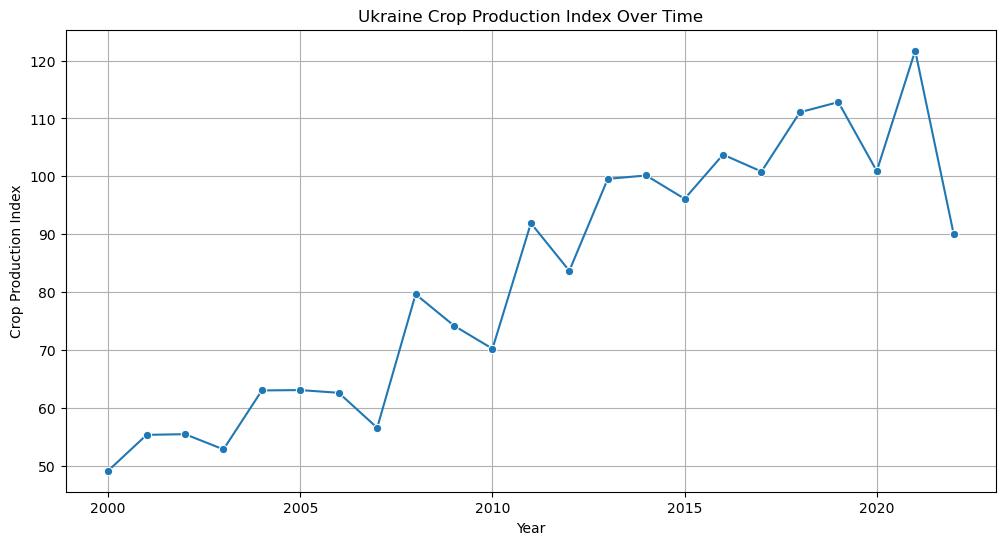

In [61]:
# Ukraine crop production trend
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=ukraine,
    x="year",
    y="crop_production_index",
    marker="o"
)
plt.title("Ukraine Crop Production Index Over Time")
plt.xlabel("Year")
plt.ylabel("Crop Production Index")
plt.grid(True)
plt.show()

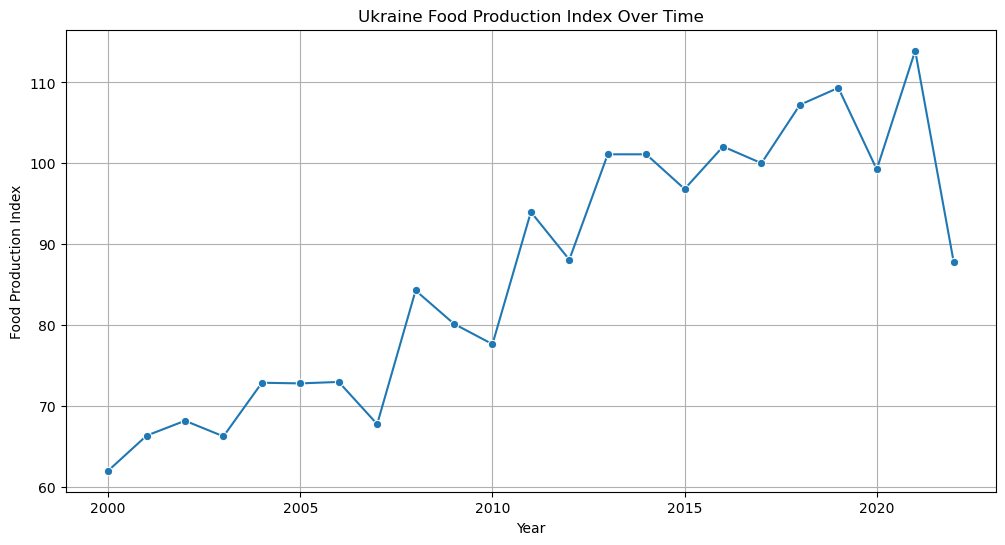

In [62]:
# Food production trend
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=ukraine,
    x="year",
    y="food_production_index",
    marker="o"
)

plt.title("Ukraine Food Production Index Over Time")
plt.xlabel("Year")
plt.ylabel("Food Production Index")
plt.grid(True)
plt.show()

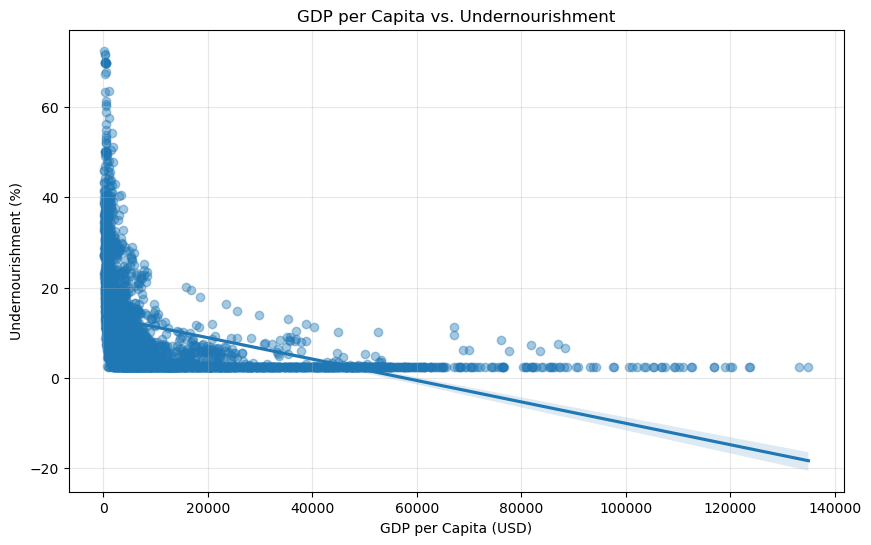

In [63]:
# GDP VS UNDERNOURISHMENT
if {
    "gdp_per_capita_usd",
    "undernourishment_pct"
}.issubset(df.columns):
    
    plt.figure(figsize=(10, 6))
    sns.regplot(
        data=df,
        x="gdp_per_capita_usd",
        y="undernourishment_pct",
        scatter_kws={"alpha": 0.4},
        line_kws={}
    )
    plt.title(
        "GDP per Capita vs. Undernourishment"
    )

    plt.xlabel("GDP per Capita (USD)")
    plt.ylabel("Undernourishment (%)")

    plt.grid(alpha=0.3)

    plt.show() 



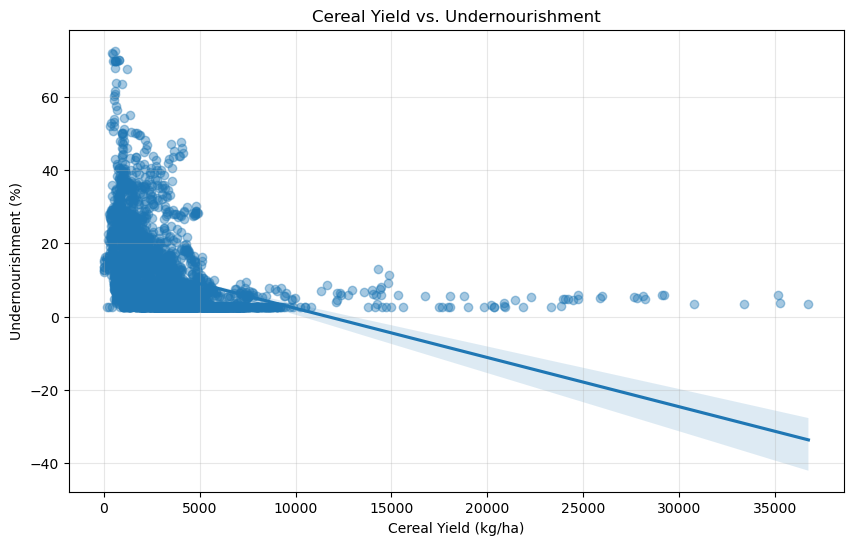

In [64]:
# CEREAL YIELD VS UNDERNOURISHMENT
if {
     "cereal_yield_kg_per_ha",
    "undernourishment_pct"
}.issubset(df.columns):
     plt.figure(figsize=(10, 6))
sns.regplot(
     data=df,
        x="cereal_yield_kg_per_ha",
        y="undernourishment_pct",
        scatter_kws={"alpha": 0.4}
)
plt.title(
        "Cereal Yield vs. Undernourishment"
    )

plt.xlabel("Cereal Yield (kg/ha)")
plt.ylabel("Undernourishment (%)")
plt.grid(alpha=0.3)
plt.show()

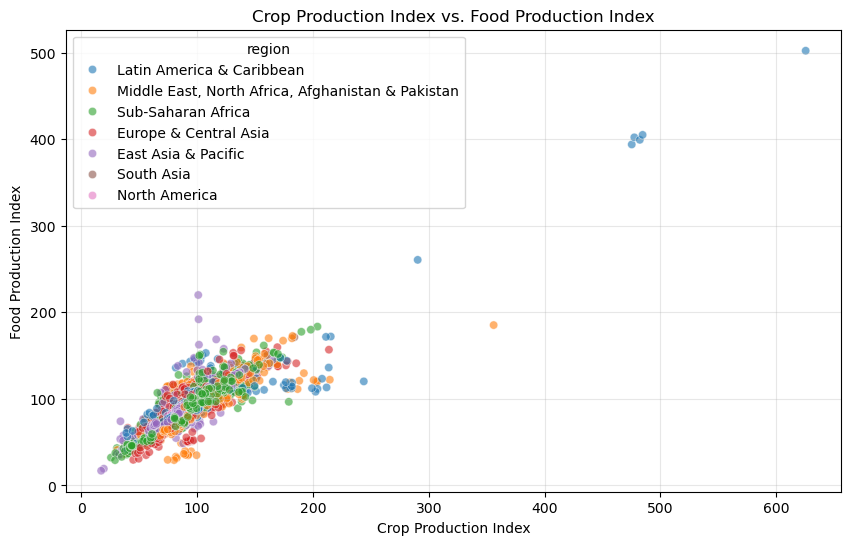

In [65]:
# CROP PRODUCTION VS FOOD PRODUCTION
if{
    "crop_production_index",
    "food_production_index"
}.issubset(df.columns):
     plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x="crop_production_index",
    y="food_production_index",
    hue="region" if "region" in df.columns else None,
    alpha=0.6
)
plt.title(
        "Crop Production Index vs. Food Production Index"
    )

plt.xlabel("Crop Production Index")
plt.ylabel("Food Production Index")
plt.grid(alpha=0.3)
plt.show()

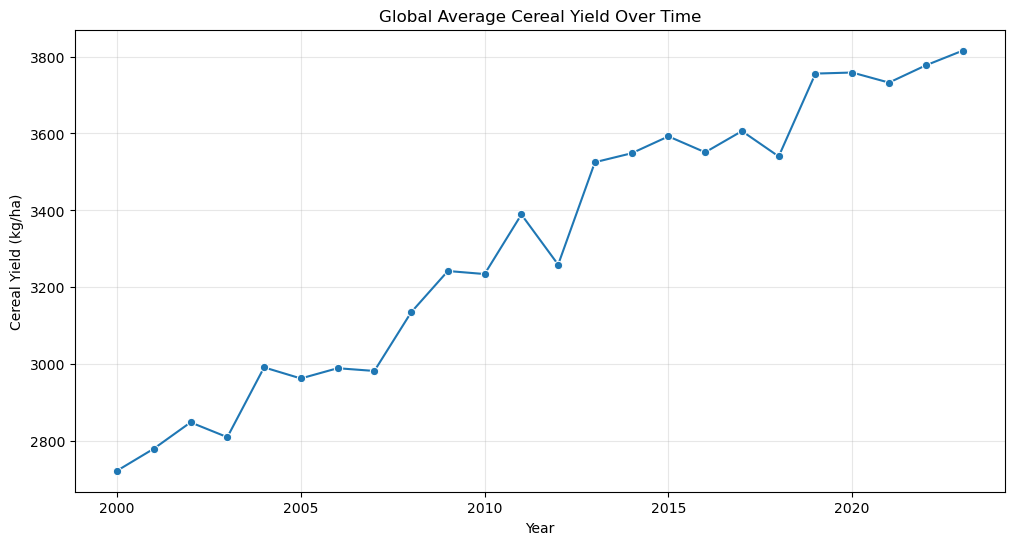

In [68]:
# GLOBAL CEREAL YIELD TREND
if {
    "year",
    "cereal_yield_kg_per_ha"
}.issubset(df.columns):
    yearly_yield = (
        df
        .groupby("year")["cereal_yield_kg_per_ha"]
        .mean()
    )
plt.figure(figsize=(12, 6))
sns.lineplot(
    x=yearly_yield.index,
    y=yearly_yield.values,
    marker="o"
)
plt.title("Global Average Cereal Yield Over Time")
plt.xlabel("Year")
plt.ylabel("Cereal Yield (kg/ha)")
plt.grid(alpha=0.3)
plt.show()

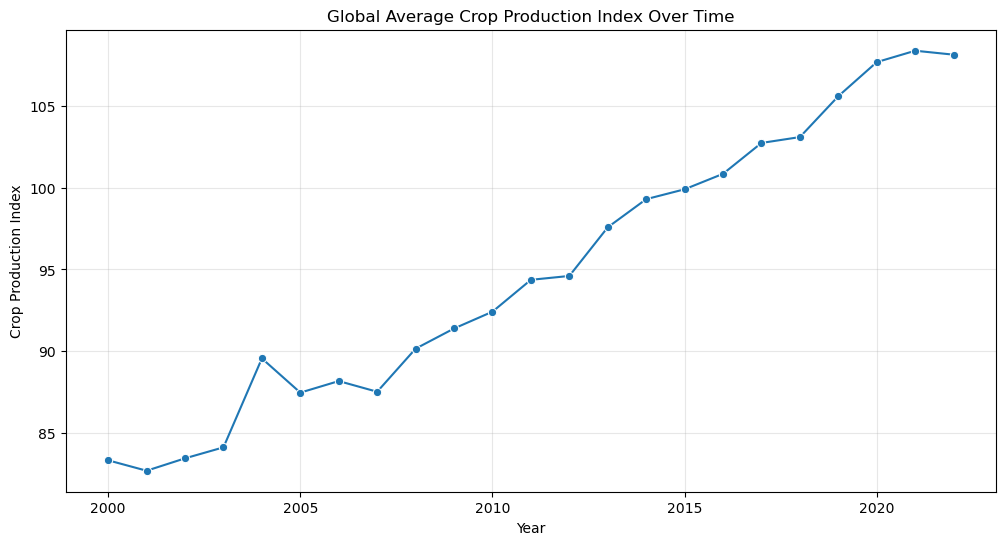

In [70]:
 # GLOBAL CROP PRODUCTION TREND

if {
    "year",
    "crop_production_index"
}.issubset(df.columns):

    yearly_crop = (
        df
        .groupby("year")["crop_production_index"]
        .mean()
    )

    plt.figure(figsize=(12, 6))

    sns.lineplot(
        x=yearly_crop.index,
        y=yearly_crop.values,
        marker="o"
    )

    plt.title(
        "Global Average Crop Production Index Over Time"
    )

    plt.xlabel("Year")
    plt.ylabel("Crop Production Index")

    plt.grid(alpha=0.3)

    plt.show()

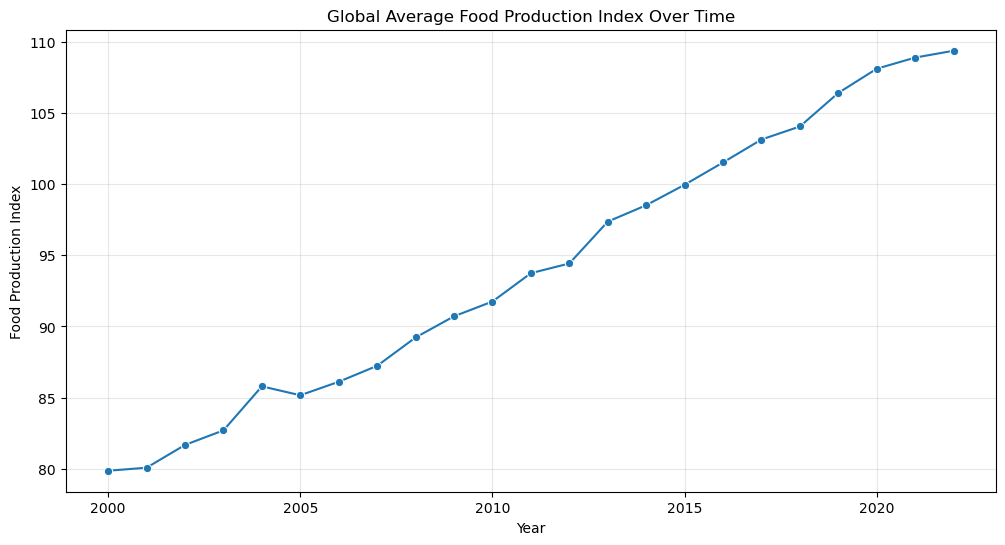

In [72]:
# GLOBAL FOOD PRODUCTION TREND
if {
    "year",
    "food_production_index"
}.issubset(df.columns):

    yearly_food = (
        df
        .groupby("year")["food_production_index"]
        .mean()
    )

    plt.figure(figsize=(12, 6))

    sns.lineplot(
        x=yearly_food.index,
        y=yearly_food.values,
        marker="o"
    )

    plt.title(
        "Global Average Food Production Index Over Time"
    )

    plt.xlabel("Year")
    plt.ylabel("Food Production Index")

    plt.grid(alpha=0.3)

    plt.show()

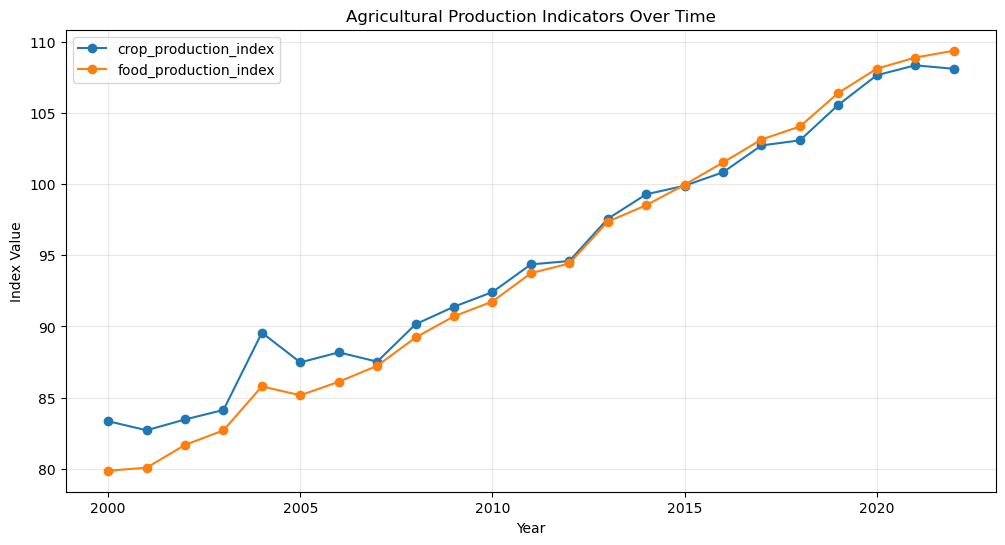

In [79]:
# AGRICULTURAL INDICATORS OVER TIME
trend_variables = [
    "crop_production_index",
    "food_production_index"
]
available_trends = [
    col for col in trend_variables
    if col in df.columns
]
yearly_trends = (
    df
    .groupby("year")[available_trends]
    .mean()
)
plt.figure(figsize=(12, 6))

for col in available_trends:
      plt.plot(
        yearly_trends.index,
        yearly_trends[col],
        marker="o",
        label=col
    )
plt.title("Agricultural Production Indicators Over Time")
plt.xlabel("Year")
plt.ylabel("Index Value")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

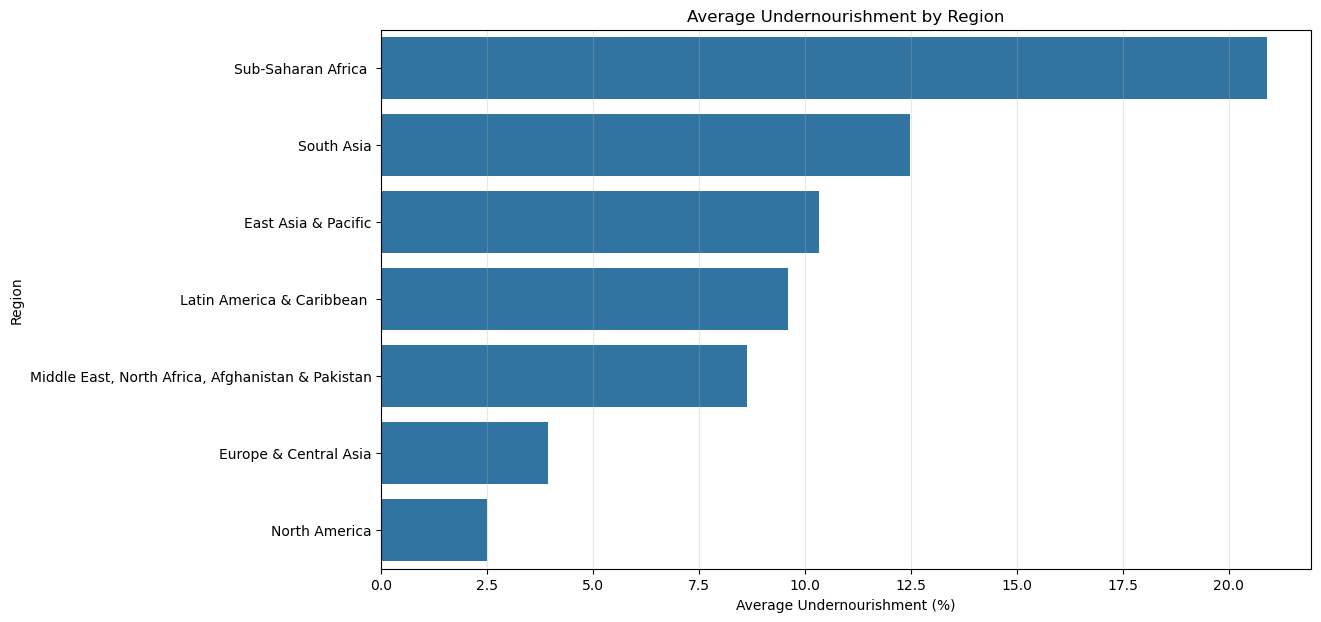

In [83]:
 # REGIONAL UNDERNOURISHMENT
if {
    "region",
    "undernourishment_pct"
}.issubset(df.columns):
    regional_under = (
    df
    .groupby("region")["undernourishment_pct"]
    .mean()
    .sort_values(ascending=False)
)
plt.figure(figsize=(12, 7))
sns.barplot(
     x=regional_under.values,
     y=regional_under.index
)
plt.title("Average Undernourishment by Region")
plt.xlabel("Average Undernourishment (%)")
plt.ylabel("Region")
plt.grid(axis="x", alpha=0.3)
plt.show()

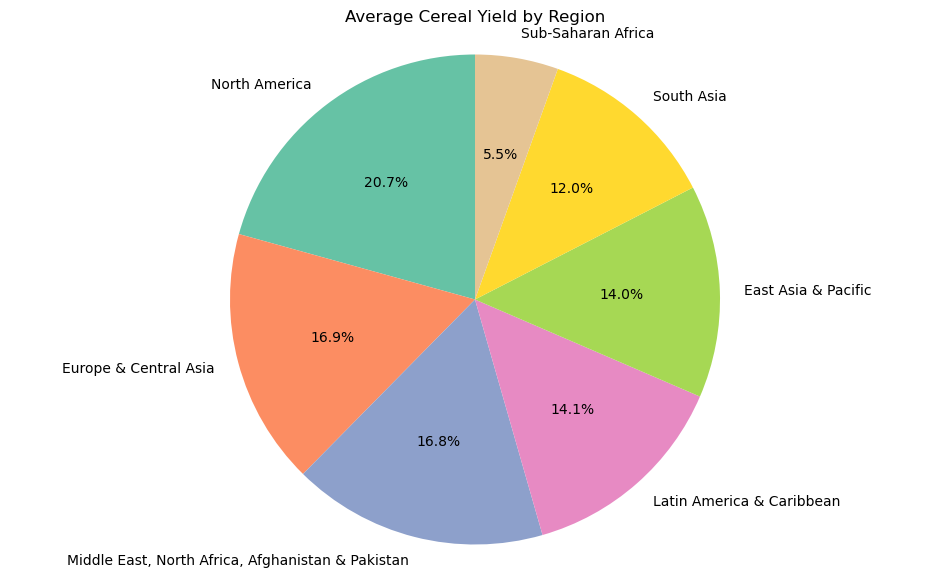

In [89]:
# REGIONAL CEREAL YIELD
if {
    "region",
    "cereal_yield_kg_per_ha"
}.issubset(df.columns):

    regional_yield = (
        df
        .groupby("region")["cereal_yield_kg_per_ha"]
        .mean()
        .sort_values(ascending=False)
    )
    plt.figure(figsize=(12, 7))

    plt.pie(
        regional_yield.values,
        labels=regional_yield.index,
        autopct="%1.1f%%",
        startangle=90,
        colors=sns.color_palette("Set2", len(regional_yield))
    )
        
    plt.title("Average Cereal Yield by Region")
    plt.axis("Equal")
    plt.show()

In [90]:
# Focused Ukraine analysis
ukraine = df[
    df["country_name"].str.lower() == "ukraine"
].copy()

ukraine = ukraine.sort_values("year")
print("Number of Ukraine observations:", len(ukraine))
display(
    ukraine[
        [
        "year",
        "cereal_yield_kg_per_ha",
        "crop_production_index",
        "food_production_index",
        "agricultural_land_pct",
        "arable_land_pct",
        "undernourishment_pct"
     ]
 ].tail(10)
)

Number of Ukraine observations: 24


,year,cereal_yield_kg_per_ha,crop_production_index,food_production_index,agricultural_land_pct,arable_land_pct,undernourishment_pct
4838,2014,4400.2,100.14,101.11,71.658409,56.569249,2.5
4839,2015,4140.9,96.11,96.82,71.653231,56.577880,2.5
4840,2016,4651.6,103.75,102.07,71.665314,56.579606,2.5
4841,2017,4314.6,100.82,100.01,71.619196,56.573451,2.6
4842,2018,4850.3,111.07,107.23,71.330687,56.763894,3.0
4843,2019,4978.3,112.83,109.33,71.299620,56.824301,3.8
4844,2020,4295.5,100.90,99.24,71.299620,56.824301,4.3
4845,2021,5454.6,121.71,113.92,71.299620,56.824301,5.3
4846,2022,4614.1,90.06,87.83,71.299620,56.824301,6.0
4847,2023,5577.1,NaN,NaN,71.299620,56.824301,6.9


In [98]:
# UKRAINE KPI CHANGE ANALYSIS
kpis_variables = [
    "cereal_yield_kg_per_ha",
    "crop_production_index",
    "food_production_index",
    "agricultural_land_pct",
    "arable_land_pct",
    "undernourishment_pct",
    "food_imports_pct_merchandise",
    "agriculture_dependence_index"
]
[col for col in kpis_variables if col in ukraine.columns]
kpi_results = []
for col in available_kpis:
    first_valid = ukraine[["year", col]].dropna().iloc[0]
    last_valid = ukraine[["year", col]].dropna().iloc[-1]

    first_value = first_valid[col]
    last_value = last_valid[col]

    percentange_change = (
        (last_value - first_value) / 
        first_value
    ) * 100
    
    kpi_results.append({
        "KPI": col,
        "Starting Year": first_valid["year"],
        "Ending Year": last_valid["year"],
        "Starting Value": first_value,
        "Ending Value": last_value,
        "Absolute Change": last_value - first_value,
        "Percentage Change (%)": percentage_change
    })
kpi_table = pd.DataFrame(kpi_results)
display(
    kpi_table.sort_values(
        "Percentage Change (%)",
        ascending=False
    )
)

,KPI,Starting Year,Ending Year,Starting Value,Ending Value,Absolute Change,Percentage Change (%)
0,cereal_yield_kg_per_ha,2000.0,2023.0,1950.800000,5577.100000,3626.300000,-20.601336
1,crop_production_index,2000.0,2022.0,49.100000,90.060000,40.960000,-20.601336
2,food_production_index,2000.0,2022.0,61.980000,87.830000,25.850000,-20.601336
3,agricultural_land_pct,2000.0,2023.0,71.469751,71.299620,-0.170130,-20.601336
4,arable_land_pct,2000.0,2023.0,56.207819,56.824301,0.616482,-20.601336
5,undernourishment_pct,2001.0,2023.0,2.700000,6.900000,4.200000,-20.601336
6,food_imports_pct_merchandise,2000.0,2023.0,55.438658,49.209146,-6.229512,-20.601336
7,agriculture_dependence_index,2000.0,2023.0,44.900000,35.650000,-9.250000,-20.601336


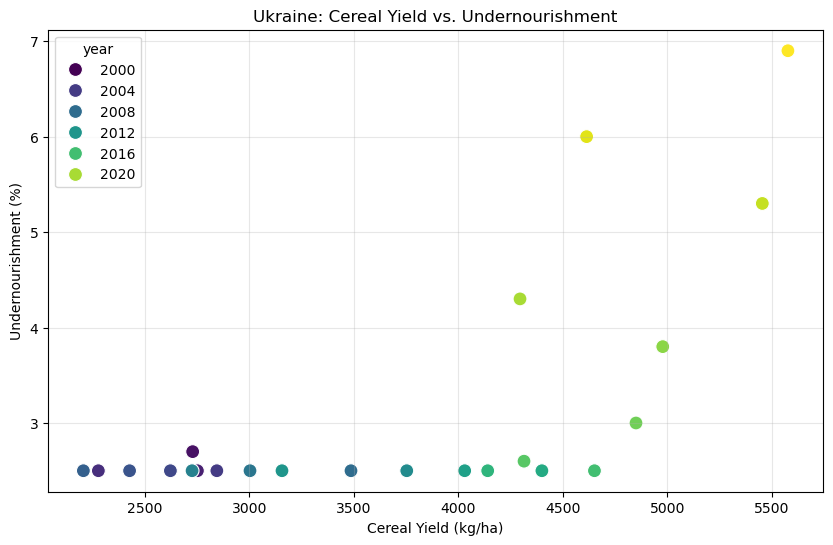

In [99]:
# UKRAINE AGRICULTURE VS FOOD SECURITY
if {
    "cereal_yield_kg_per_ha",
    "undernourishment_pct"
}.issubset(ukraine.columns):
    plt.figure(figsize=(10, 6))

    sns.scatterplot(
        data=ukraine,
        x="cereal_yield_kg_per_ha",
        y="undernourishment_pct",
        hue="year",
        palette="viridis",
        s=100
    )
    plt.title("Ukraine: Cereal Yield vs. Undernourishment")
    plt.xlabel("Cereal Yield (kg/ha)")
    plt.ylabel("Undernourishment (%)")
    plt.grid(alpha=0.3)
    plt.show()

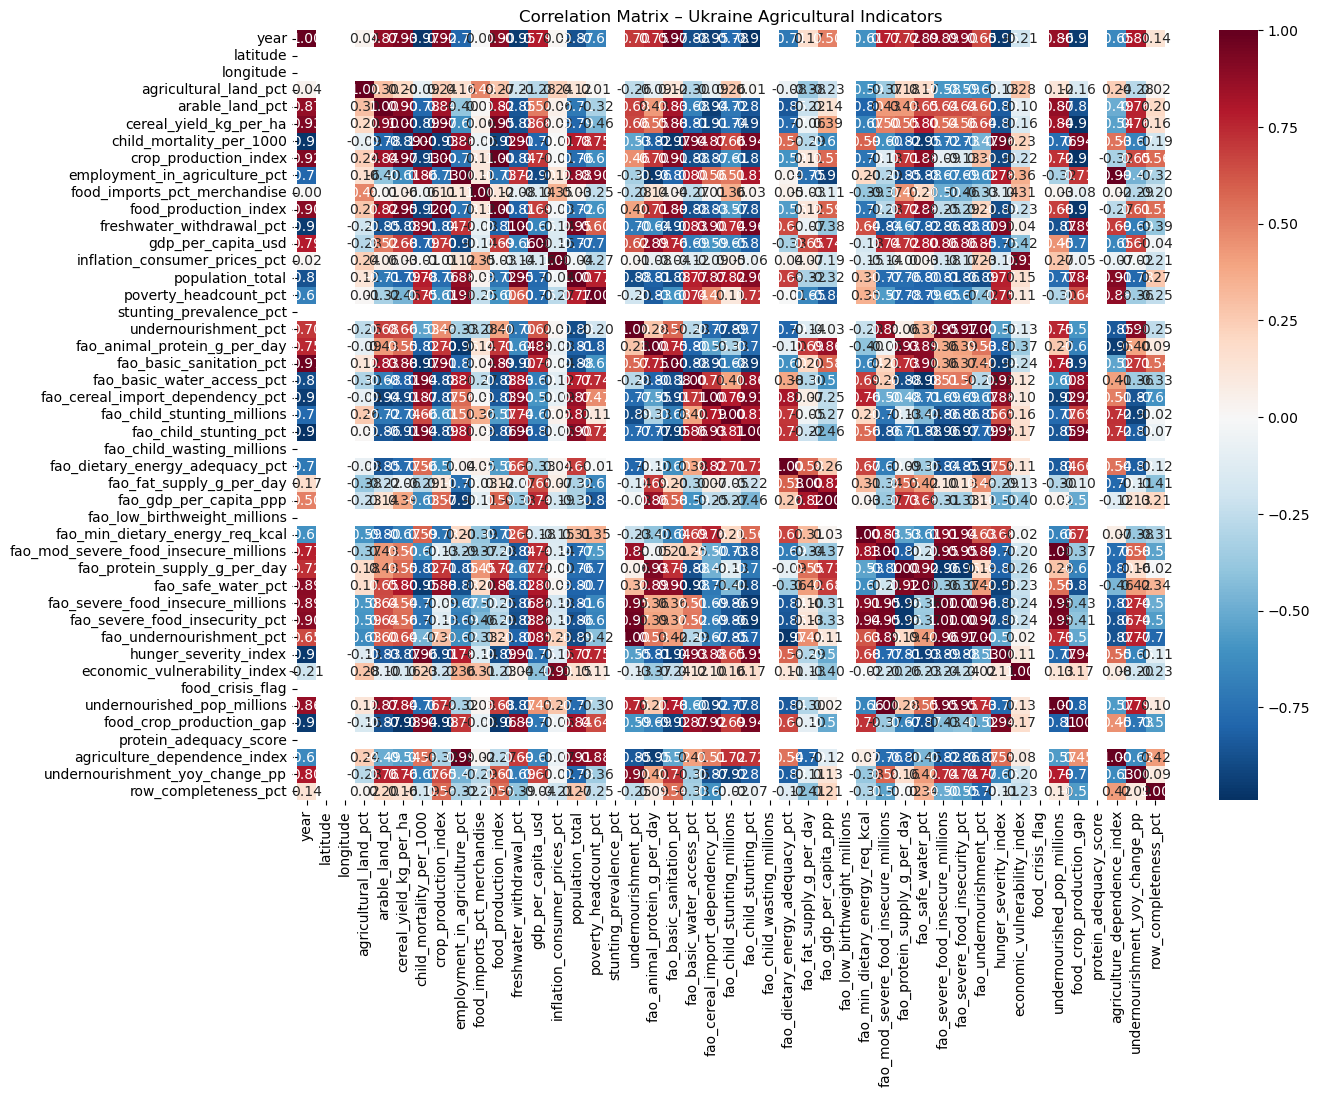

In [101]:
# UKRAINE CORRELATION MATRIX
ukraine_numeric = ukraine.select_dtypes(
    include=np.number
)
ukraine_corr = ukraine_numeric.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(
    ukraine_corr,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0
)
plt.title("Correlation Matrix – Ukraine Agricultural Indicators")
plt.show()

In [103]:
# COUNTRY BENCHMARKING
if{
    "country_name",
    "cereal_yield_kg_per_ha"
}.issubset(df.columns):

    country_yield = (
        df
        .groupby("country_name")["cereal_yield_kg_per_ha"]
        .mean()
        .dropna()
        .sort_values(ascending=False)
    )
    print("Top 10 countries:")
    display(country_yield.head(10))
    print("Bottom 10 countries:")
    display(country_yield.tail(10))

Top 10 countries:


country_name
United Arab Emirates              22323.945833
St. Vincent and the Grenadines    19539.616667
Oman                              11294.687500
Kuwait                            10916.129167
Belgium                            8694.120833
Netherlands                        8172.941667
Ireland                            7703.975000
New Zealand                        7646.670833
Egypt, Arab Rep.                   7205.512500
United States                      7145.529167
Name: cereal_yield_kg_per_ha, dtype: float64

Bottom 10 countries:


country_name
Lesotho               674.633333
Libya                 652.520833
Somalia, Fed. Rep.    609.850000
Sudan                 590.087500
Eritrea               579.220833
Vanuatu               577.383333
Niger                 456.166667
Namibia               444.262500
Botswana              370.970833
Cabo Verde            200.300000
Name: cereal_yield_kg_per_ha, dtype: float64

In [106]:
# UKRAINE VS REGIONAL AVERAGE
if "region" in ukraine.columns:
    ukraine_region = ukraine["region"].dropna().iloc[0]

    regional_data = df[
        df["region"] == ukraine_region
    ]
    comparison = pd.DataFrame({
        "Ukraine": ukraine[
            "cereal_yield_kg_per_ha"
        ].mean(),

        "Regional Average": regional_data[
            "cereal_yield_kg_per_ha"            
        ].mean()
    }, index=["Average Cereal Yield"])
    display(comparison)

,Ukraine,Regional Average
Average Cereal Yield,3635.3875,4328.973244


"""
The data analysis demonstrates that agricultural production and food security are closely connected, although increases in agricultural productivity do not automatically eliminate food insecurity. From 1991 to 2023, the visualizations show changes in key agricultural KPIs, including crop production, food production, cereal yield, agricultural land, arable land and undernourishment. For Ukraine, the analysis demonstrates that agricultural performance changed substantially over this period, with improvements in cereal yield indicating increased productivity, while changes in agricultural and arable land show shifts in the use of productive land. The crop analysis also demonstrated that Sunflower planted area increased by approximately 158.5 thousand hectares per year, while Sugar Beet planted area decreased by approximately 45.4 thousand hectares per year between 1991 and 2023. Similarly, Sunflower production increased by approximately 455.9 thousand tonnes per year, whereas Sugar Beet production decreased by approximately 541.5 thousand tonnes per year. The yield KPI improved across the major crop groups, with Cereals & Legumes increasing from 2.64 tonnes/ha in 1991 to 5.44 tonnes/ha in 2023, while Fruits & Berries increased from 1.82 tonnes/ha to 10.67 tonnes/ha. These results demonstrate that Ukraine achieved important gains in agricultural productivity, but changes in crop areas and food-security indicators show that increased production alone is not sufficient to guarantee improved food security. It is therefore recommended that policymakers focus on increasing cereal yield, protecting productive agricultural and arable land, promoting crop diversification, supporting farmers with improved technology and quality inputs and strengthening domestic food production. Progress should be continuously measured using the KPIs of cereal yield (tonnes/ha), crop production, food production, agricultural land, arable land, planted area, production growth and undernourishment, comparing changes from 1991 to 2023 to ensure that improvements in agricultural productivity translate into sustainable food-security outcomes.

"""